In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import sys
import numpy as np
from collections import defaultdict, Counter
import ast
from collections import defaultdict

In [2]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})


# (c) Mutagenesis activity in Library 1

In [11]:
df=pd.read_csv('../Summary_all.csv')
df=df[df['Library']=="Lib_1"]
filtered_df = df[['TR', 'percentage_mutants']]
# Group by 'TR' and calculate the average of 'percentage_mutants'
grouped_df = filtered_df.groupby('TR')['percentage_mutants'].mean().reset_index()

Text(0, 0.5, 'Survival')

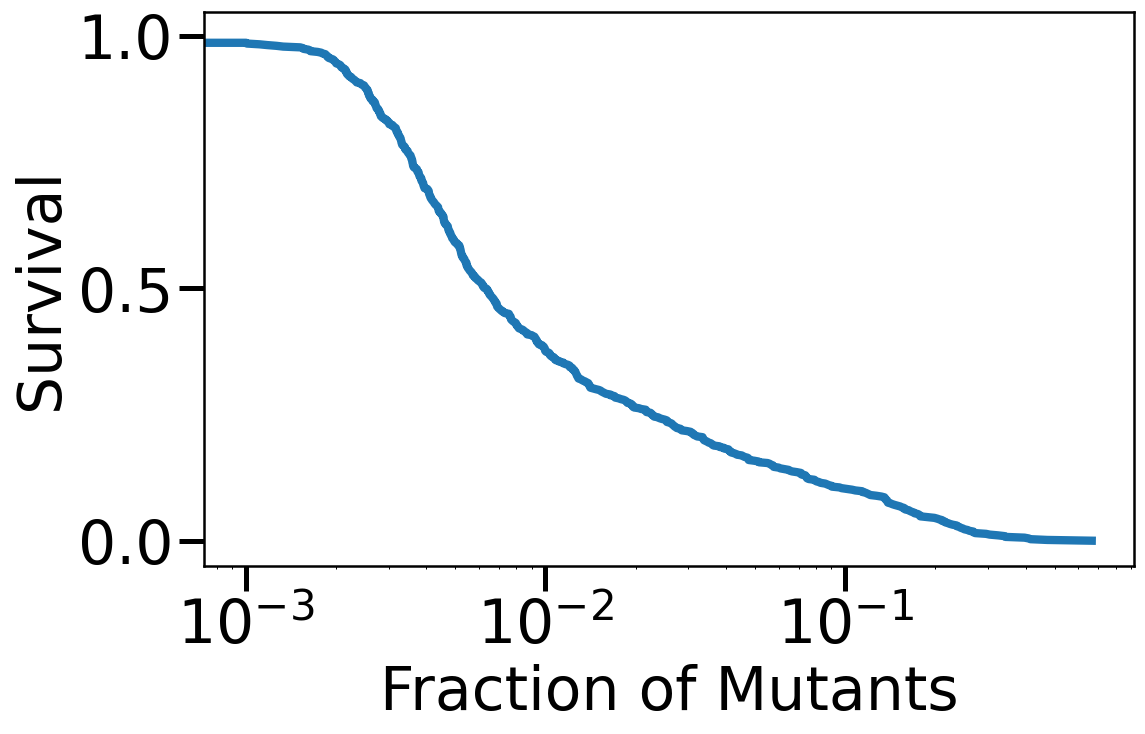

In [19]:
# Plot tail distributions for all libraries
plt.figure(figsize=(10,6))
data=list(grouped_df['percentage_mutants'])
sorted_data = np.sort(data)
sf = 1 - np.arange(1, len(sorted_data)+1)/len(sorted_data)
plt.plot(sorted_data/100, sf, label='Lib 1')


plt.semilogx()

plt.xscale('log')
plt.xlabel('Fraction of Mutants')
plt.ylabel('Survival')

# (d) Mutation profile 

In [3]:
def mutational_profile_from_counter(TR, VR):
    """
    TR: str (reference sequence)
    VR: Counter({sequence: count})
    
    Returns:
        mutation_freq: dict[base][position] = % mutated UMIs
    """
    L = len(TR)
    total_umis = sum(VR.values())

    # Count mutations per position
    mutation_counts = {i: Counter() for i in range(L)}

    for seq, count in VR.items():
        for i, (ref, obs) in enumerate(zip(TR, seq)):
            if ref != obs:
                mutation_counts[i][obs] += count

    # Convert to percentages
    mutation_types = ["A", "T", "G", "C"]
    mutation_freq = {b: np.zeros(L) for b in mutation_types}

    for i in range(L):
        for b in mutation_types:
            mutation_freq[b][i] = (
                mutation_counts[i][b] / total_umis * 100
                if b in mutation_counts[i]
                else 0
            )

    return mutation_freq

def plot_mutational_profile(TR, mutation_freq):
    mutation_palette = {
        "A": "#F28E2B",
        "T": "r",
        "G": "g",
        "C": "b"
    }

    positions = np.arange(len(TR))
    bottom = np.zeros(len(TR))

    plt.figure(figsize=(14, 4))

    for base in ["A", "T", "G", "C"]:
        plt.bar(
            positions,
            mutation_freq[base],
            bottom=bottom,
            color=mutation_palette[base],
            label=base
        )
        bottom += mutation_freq[base]

    plt.xticks(
        ticks=positions,
        labels=list(TR),
        fontsize=14,
        fontfamily="monospace"
    )
    plt.xlabel("Position in Sequence", fontsize=16)
    plt.ylabel("% mutated UMIs", fontsize=16)
    plt.title("Mutational Profile Across TR")
    plt.legend(title="Mutation Type")
    plt.ylim(0, 60)
    plt.tight_layout()


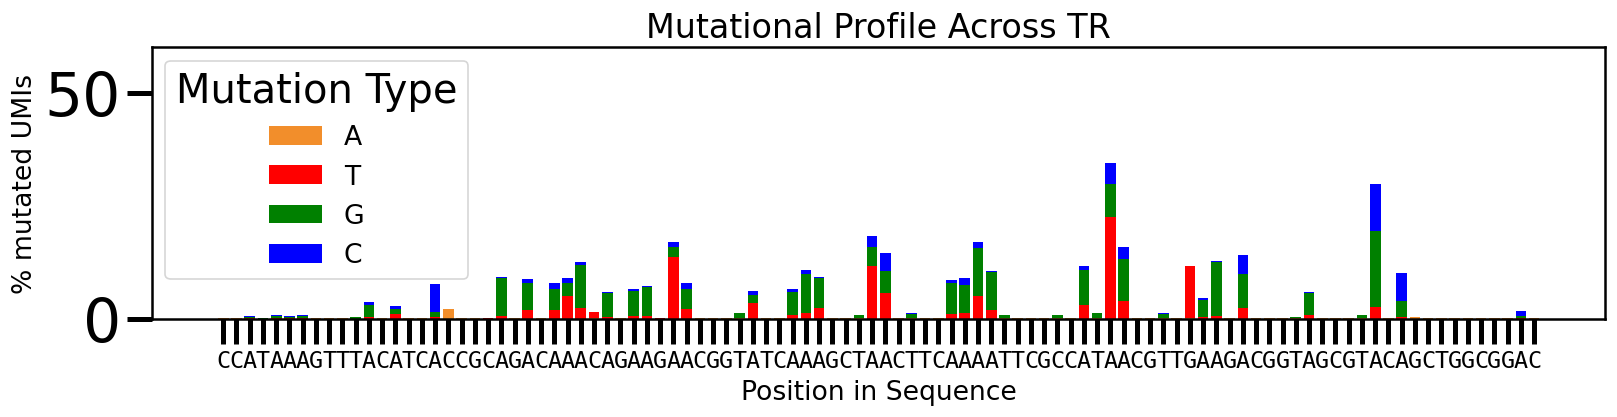

In [4]:
df = pd.read_csv("../Summary_all.csv",index_col=False)
# Convert stringified dicts to dicts (once)
df['Mutants'] = df['Mutants'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_Lib2=df[df['Library']=='Lib_2']
df_Lib2=df_Lib2[df_Lib2['percentage_mutants']>3]

TR=list(df_Lib2['TR'])[0]
VR=df[df['TR']==TR]

# Precompute weighted value
VR['weighted_mut'] = VR['percentage_mutants'] * VR['TR_count']

VR = (
    VR
    .groupby(['TR', 'Library'], as_index=False)
    .agg(
        TR_count=('TR_count', 'sum'),
        weighted_mut=('weighted_mut', 'sum'),
        Mutants=('Mutants', lambda x: dict(sum((Counter(d) for d in x), Counter())))
    )
)

# Final weighted average
VR['percentage_mutants'] = VR['weighted_mut'] / VR['TR_count']

# Cleanup
VR = VR.drop(columns='weighted_mut')
VR=VR['Mutants'][0]

mutation_freq = mutational_profile_from_counter(TR, VR)
plot_mutational_profile(TR, mutation_freq)